<a href="https://colab.research.google.com/github/2403A54074/NLP/blob/main/Lab10_tSNE_Embeddings_NAYINI_KALYAN_REDDY_2403A54074.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.5 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api # Used for downloading and loading pre-trained word embedding models.
import numpy as np # Provides support for large, multi-dimensional arrays and matrices, essential for numerical operations.
import pandas as pd # A powerful data manipulation and analysis library, useful for handling data frames.
import matplotlib.pyplot as plt # Used for creating static, interactive, and animated visualizations.
from sklearn.manifold import TSNE # Implements t-Distributed Stochastic Neighbor Embedding for dimensionality reduction.

print("All necessary libraries imported successfully.")

All necessary libraries imported successfully.


In [ ]:
print("Loading pre-trained word embedding model 'glove-wiki-gigaword-50'...")
model = api.load("glove-wiki-gigaword-50")
print("Model loaded successfully.")

# Print the vocabulary size
vocabulary_size = len(model.key_to_index)
print(f"Vocabulary size of the loaded model: {vocabulary_size}")

# Choose a common word and display its vector representation
chosen_word = 'king'
word_vector = model[chosen_word]
print(f"\nVector for the word '{chosen_word}':")
print(word_vector)
print(f"Shape of the vector for '{chosen_word}': {word_vector.shape}")

Loading pre-trained word embedding model 'glove-wiki-gigaword-50'...
[==================================================] 100.0% 66.0/66.0MB downloaded
Model loaded successfully.
Vocabulary size of the loaded model: 400000

Vector for the word 'king':
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]
Shape of the vector for 'king': (50,)


In [ ]:
selected_words = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'apple', 'banana', 'orange', 'grape', 'strawberry',
    'car', 'truck', 'bicycle', 'motorcycle', 'airplane',
    'doctor', 'nurse', 'engineer', 'teacher', 'artist',
    'happy', 'sad', 'angry', 'joy', 'love',
    'france', 'germany', 'italy', 'spain', 'japan',
    'dog', 'cat', 'bird', 'fish', 'horse'
]

word_vectors_list = []
actual_words = []

print(f"Attempting to extract vectors for {len(selected_words)} words...")

for word in selected_words:
    try:
        # Check if the word is in the model's vocabulary
        if word in model.key_to_index:
            word_vectors_list.append(model[word])
            actual_words.append(word)
        else:
            print(f"Warning: Word '{word}' not found in model vocabulary and will be skipped.")
    except KeyError:
        # This catch block is mostly for robustness, as the `if word in model.key_to_index` check should prevent KeyErrors
        print(f"Error: Could not retrieve vector for '{word}'. Skipping.")

# Convert the list of word vectors to a NumPy array
word_vectors = np.array(word_vectors_list)

print(f"Successfully extracted vectors for {len(actual_words)} words.")
print(f"Shape of the word_vectors array: {word_vectors.shape}")


Attempting to extract vectors for 36 words...
Successfully extracted vectors for 36 words.
Shape of the word_vectors array: (36, 50)


In [ ]:
print("Applying t-SNE for dimensionality reduction...")

tsne = TSNE(n_components=2, random_state=42, perplexity=15)

# Apply t-SNE to the word vectors
tsne_coords = tsne.fit_transform(word_vectors)

print("t-SNE dimensionality reduction complete.")
print(f"Shape of 2-D t-SNE coordinates: {tsne_coords.shape}")

Applying t-SNE for dimensionality reduction...
t-SNE dimensionality reduction complete.
Shape of 2-D t-SNE coordinates: (36, 2)


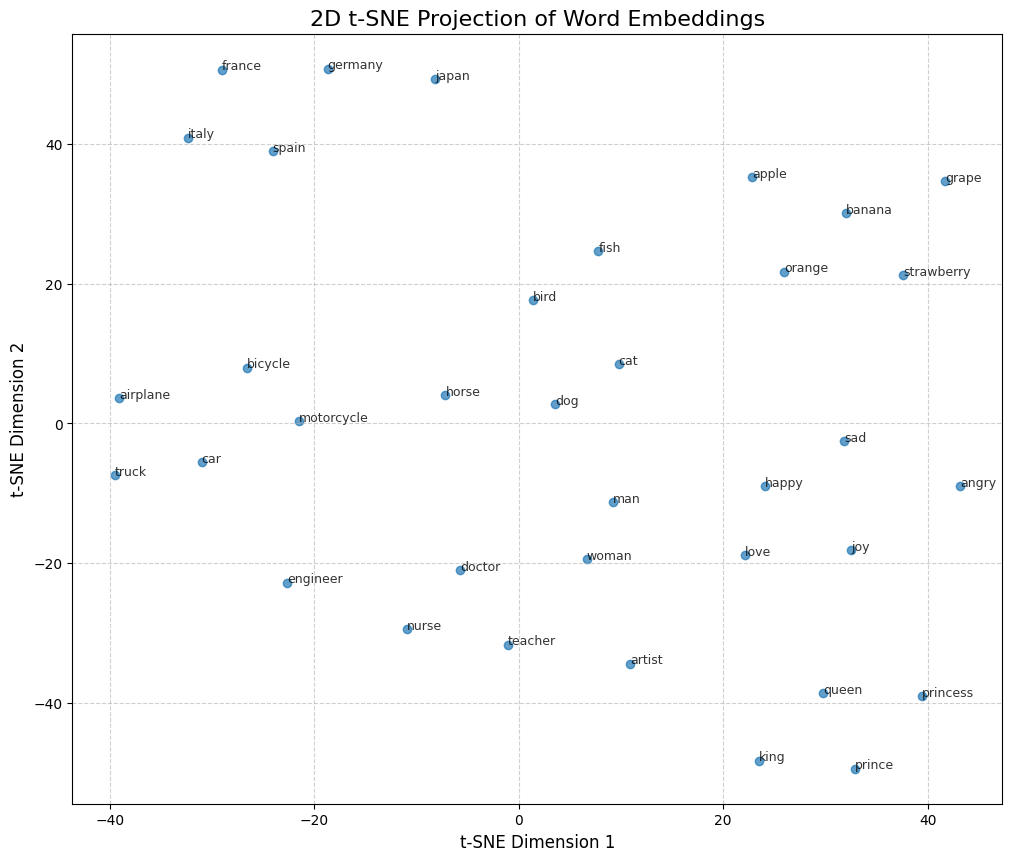

2-D t-SNE projection of word embeddings plotted successfully.


In [ ]:
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability

# Create the scatter plot
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], alpha=0.7)

# Annotate each point with its corresponding word
for i, word in enumerate(actual_words):
    plt.annotate(word, (tsne_coords[i, 0], tsne_coords[i, 1]), fontsize=9, alpha=0.8)

# Add plot title and labels
plt.title('2D t-SNE Projection of Word Embeddings', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Add grid for better orientation
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()
print("2-D t-SNE projection of word embeddings plotted successfully.")